In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax.numpy as jnp
from jax import jit
import jax
from ksd import compute_ksd_jax
from jax import vmap, grad
import matplotlib.pyplot as plt
import numpy as np
from ot.lp import wasserstein_1d as wd
from tqdm.auto import tqdm

from triangular_transport.mcmc.adaptive_mcmc import AdaptiveMCMC
from triangular_transport.kernels.kernel_tools import get_gaussianRBF, get_sum_of_kernels, vectorize_kfunc

plt.style.use("ggplot")

/home/verano13/miniconda3/envs/stochastic-interpolants/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
a = 2
b = 0.1
sigma_x = 1
cond_no = -1.0
nsamples = 100000

@jit
def density_V(u):
    y = cond_no
    scale = 1 / (2 * sigma_x**2)
    sum_part = (a * (y + b * (u**2 + a**2))) ** 2 + (u**2) / (a**2)
    return jnp.squeeze(jnp.exp(-scale * sum_part))

def alpha(x, w, log_density):
    log_w = log_density(w)
    log_x = log_density(x)
    return jnp.minimum(0.0, log_w - log_x)

In [6]:
no_trials = 10
nsamples = 100000
adapt_mcmc_samps = np.zeros((no_trials, nsamples, 1))
for i in range(no_trials):
    adapt_mcmc = AdaptiveMCMC(
        target_density=density_V,
        alpha_function=alpha,
        seed=i,
        train_dim=1,
        steps=nsamples,
        name="Adaptive - Conditional",
        std_err=0.6,
        iter_step_adapt=1,
        cond_no=cond_no,
        burn_in=1, # TODO: Rerun everything with low burn_in
    )
    adapt_mcmc.fit(print_every=20000)
    adapt_mcmc_samps[i, :, :] = adapt_mcmc.samples

 20%|██        | 20112/100001 [00:28<01:51, 719.38it/s]

The acceptance rate is: 0.7501


 40%|████      | 40141/100001 [00:56<01:22, 727.58it/s]

The acceptance rate is: 0.74865


 60%|██████    | 60130/100001 [01:23<00:54, 733.48it/s]

...

The acceptance rate is: 0.7425


 80%|████████  | 80088/100001 [04:43<00:27, 714.79it/s]

The acceptance rate is: 0.740625


100%|██████████| 100001/100001 [05:12<00:00, 320.15it/s]

The acceptance rate is: 0.74028


In [2]:
seed = 1
choose_samples = 20000
rng = np.random.RandomState(seed)
samps = np.load("rej_samples_1.npy")[
    rng.choice(100000, size=(choose_samples,)), :
]

In [3]:
sample_no_list = [2**i for i in range(1, 15)]
sample_no_list.append(20000)
sample_no_list.append(30000)
sample_no_list.append(40000)
sample_no_list.append(50000)
sample_no_list.append(60000)
sample_no_list.append(70000)
sample_no_list.append(80000)
sample_no_list.append(90000)
sample_no_list.append(100000)

In [4]:
adapt_mcmc_samps = np.load("mcmc_results/mcmc_samps.npy")

In [5]:
adapt_mcmc = adapt_mcmc_samps[0]

In [13]:
from ot.lp import wasserstein_1d
no_trials = 10
wd_array = np.zeros((no_trials, len(sample_no_list)))

for j in tqdm(range(no_trials)):
    for i, sample_no in enumerate(sample_no_list):
        wd1 = wd(
            adapt_mcmc_samps[j, :sample_no, :].reshape(-1),
            samps.reshape(-1),
            p=2.
        )

        wd_array[j, i] = wd1

100%|██████████| 10/10 [00:01<00:00,  9.05it/s]


In [14]:
avg_wd_array = np.mean(wd_array, axis=0)
std_wd_array = np.std(wd_array, axis=0)

In [15]:
us_base = rng.randn(20000, 1)
base_wd = wasserstein_1d(
    us_base.reshape(-1),
    samps.reshape(-1),
)

In [16]:
rel_wd_array = avg_wd_array / base_wd
# rel_wd_array = wd_array / base_wd

In [21]:
si_array = np.zeros((10, 23))
for i in range(3):
    si_array[i, :] = np.load(f"converge_results_banana/run_{i:02d}/nn_conv_wd_{i}.npy")

In [22]:
si_mean = np.mean(si_array, axis=0)
si_std = np.std(si_array, axis=0)

In [29]:
rel_wd_array.squeeze()

array([9.12016595e+00, 3.42056548e+00, 2.50710924e+00, 2.47167382e+00,
       7.66056940e-01, 5.22303991e-01, 5.37652321e-01, 1.14821957e+00,
       1.97858629e-01, 2.79542720e-02, 6.15847536e-02, 5.12560340e-03,
       1.99855789e-03, 1.59821788e-03, 2.95155445e-03, 6.13793691e-03,
       7.87790689e-03, 3.95391221e-03, 4.27056060e-03, 2.28232895e-03,
       2.48274104e-03, 2.32843665e-03, 1.57900533e-03])

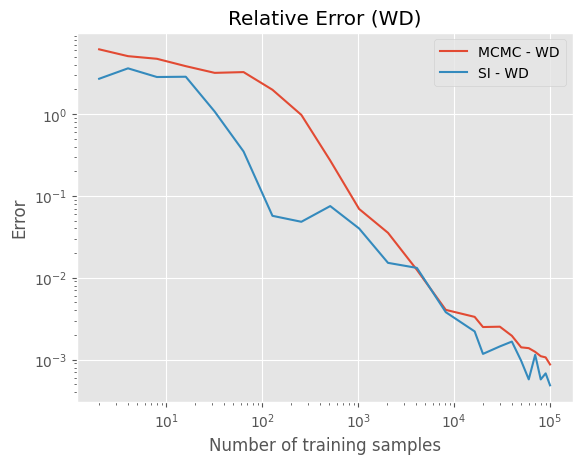

In [24]:
# plt.plot(sample_no_list, rel_swd_array, label="SWD")
plt.plot(sample_no_list, rel_wd_array, label="MCMC - WD")
plt.plot(sample_no_list, si_mean, label="SI - WD")
# plt.plot(sample_no_list, 1 / np.sqrt(sample_no_list))
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of training samples")
plt.ylabel("Error")
plt.title("Relative Error (WD)")
plt.legend()

In [91]:
log_n = np.log(sample_no_list)
log_err = np.log(rel_wd_array)

mask = np.array(sample_no_list) >= 1000
slope, intercept = np.polyfit(log_n[mask], log_err[mask], deg=1)

print("slope = ", slope)
print("intercept = ", intercept)

slope =  -0.4530727113527438
intercept =  1.497307204781653


In [92]:
np.save("mcmc_results/rel_wd_array_mcmc.npy", rel_wd_array)
np.save("mcmc_results/mcmc_samps.npy", adapt_mcmc_samps)

In [11]:
rel_wd_array_mcmc = np.load("mcmc_results/rel_wd_array_mcmc.npy")
si_array = np.zeros((10, 23))
for i in range(10):
    si_array[i, :] = np.load(f"converge_results_banana/run_{i:02d}/nn_conv_wd_{i}.npy")

In [12]:
si_mean = np.mean(si_array, axis=0)
si_std = np.std(si_array, axis=0)

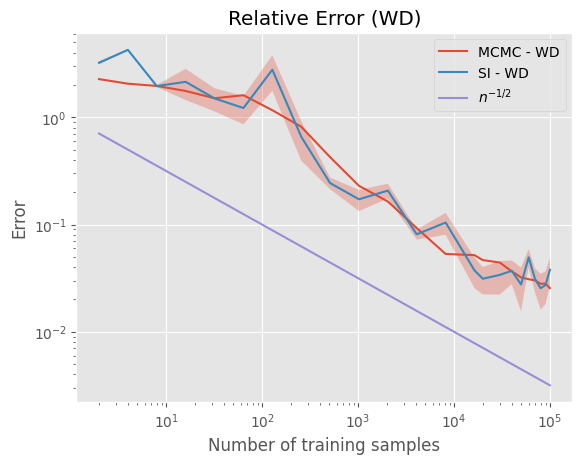

In [14]:
plt.plot(sample_no_list, rel_wd_array_mcmc, label="MCMC - WD")
plt.plot(sample_no_list, si_mean, label="SI - WD")
plt.plot(sample_no_list, 1 / np.sqrt(sample_no_list), label=r"$n^{-1/2}$")
plt.fill_between(
    sample_no_list,
    si_mean - si_std,
    si_mean + si_std,
    alpha=0.3,
)
# plt.fill_between(
#     sample_no_list,
#     rel_wd_array_mcmc - std_wd_array,
#     rel_wd_array_mcmc + std_wd_array,
#     alpha=0.3,
# )
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of training samples")
plt.ylabel("Error")
plt.title("Relative Error (WD)")
plt.legend()

In [15]:
log_n = np.log(sample_no_list)
log_err = np.log(si_mean)

mask = np.array(sample_no_list) >= 1000
slope, intercept = np.polyfit(log_n[mask], log_err[mask], deg=1)

print("slope = ", slope)
print("intercept = ", intercept)

slope =  -0.4262695535426936
intercept =  1.23865634755757


In [16]:
log_n = np.log(sample_no_list)
log_err = np.log(rel_wd_array_mcmc)

mask = np.array(sample_no_list) >= 1000
slope, intercept = np.polyfit(log_n[mask], log_err[mask], deg=1)

print("slope = ", slope)
print("intercept = ", intercept)

slope =  -0.4530727113527438
intercept =  1.497307204781653


In [29]:
mcmc_samps = np.load("mcmc_results/mcmc_samps.npy")
from ot.lp import wasserstein_1d
wd_array = np.zeros((10, len(sample_no_list)))

for j in tqdm(range(10)):
    for i, sample_no in enumerate(sample_no_list):
        wd1 = wasserstein_1d(
            mcmc_samps[j, :sample_no, :].reshape(-1),
            samps.reshape(-1),
        )

        wd_array[j, i] = wd1

100%|██████████| 10/10 [00:00<00:00, 10.69it/s]


In [31]:
wd_array.shape

(10, 23)

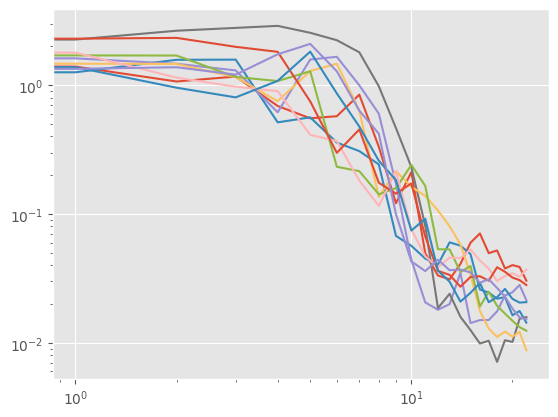

In [33]:
for i in range(10):
    plt.plot(wd_array[i, :])
    plt.yscale("log")
    plt.xscale("log")

In [39]:
std_wd_array = np.std(wd_array, axis=0)

In [40]:
std_wd_array

array([0.32049199, 0.35108084, 0.5116693 , 0.55176469, 0.69993621,
       0.68794401, 0.65587021, 0.45539492, 0.25699712, 0.10369095,
       0.07638453, 0.04398094, 0.02359336, 0.01762366, 0.01314878,
       0.01485165, 0.01659368, 0.01143449, 0.01251544, 0.00887435,
       0.00973808, 0.0088447 , 0.00847757])

In [ ]:
rel_wd_array_mcmc